In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_datadicts_from_db
from ase.io import read,write
from ase.db import connect
from sklearn.manifold import TSNE


-1526.0585172002247


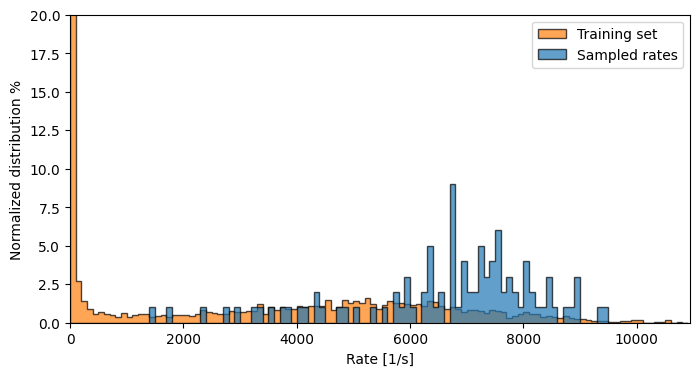

In [4]:
atoms_list = read(filename="../../results/optimization/genetic_algorithm/filtered_samples.traj", index=":")
train_datadicts = [{"elements":atoms.get_chemical_symbols(), "rate":atoms.info["rate"]} for atoms in atoms_list]
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])
#element_pool = ["Rh", "Cu", "Pd", "Au"]

samples_pth = "full_surface/full_model_test_2/samples"
rate_cond = 8000.0
miller_index = "100"
database = Database.establish_connection(
    filename=f"rate_{rate_cond}_evals.db",
    pth_header=samples_pth
    )
datadicts = load_datadicts_from_db(database=database)
sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
#sampled_atoms = []
#for iter in [0,1,2,3,4]:
#    sampled_atoms += read(filename=f"../../active_learning/samples_iter_{iter}.traj", index=":")
#sampled_rates = np.array([atoms.info["rate"] for atoms in sampled_atoms])
#write("tot_act_sampled.traj", sampled_atoms)
print(np.max(sampled_rates)-np.max(train_rates))
fig, ax = plt.subplots(figsize=(8,4))
train_rates#rates = np.array([datadict["rate"] for datadict in datadicts])
rate_interval = 100.0
rate_max = np.max(train_rates)
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.20*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()